In [1]:
import pandas as pd

# Data
Source: https://cseweb.ucsd.edu/~jmcauley/pdfs/recsys21b.pdf
This is a dataset of users consuming streaming content on Twitch. We retrieved all streamers, and all users connected in their respective chats, every 10 minutes in July 2019 over a 43-day period

In [16]:
twitchdf = pd.read_csv('https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/100k_a.csv', header=None, names=["UserID", "StreamID", "Streamer Username", "Time Start", "Time Stop"])
twitchdf.head()

,UserID,StreamID,Streamer Username,Time Start,Time Stop
0,1,33842865744,mithrain,154,156
1,1,33846768288,alptv,166,169
2,1,33886469056,mithrain,587,588
3,1,33887624992,wtcn,589,591
4,1,33890145056,jrokezftw,591,594


<Axes: xlabel='Streamer Username'>

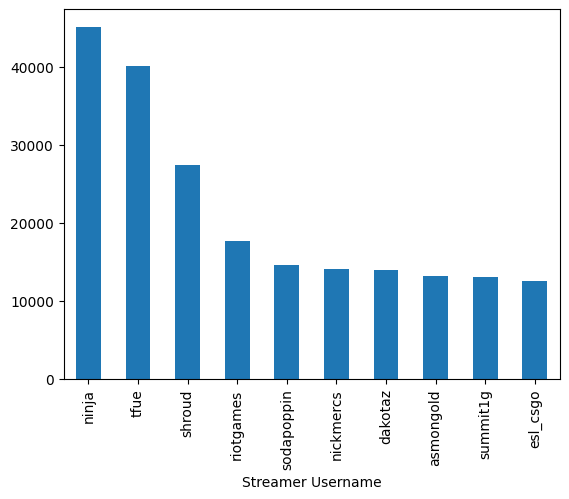

In [9]:
twitchdf["Streamer Username"].value_counts()[:10].plot(kind="bar")

In [15]:
len(twitchdf["Streamer Username"].value_counts())

162625

# 1. Predictive Task
- We will build a recommender system that predicts if you will watch a streamer or not (AKA a Twitch streamer recommender).
- First we will prep the data to just user-streamer interactions, 1 if they interacted, 0 if they did not. We will have to generate a dataset of negatives (a dataset of did not interact) ourselves on a 9:1 ratio. This reflects real world scenarios where most users really only watch a handful of streamers while also still being not too computationally expensive.
- To evaluate the model, we will split the data to 80% for training and 20% for testing. Both splits will maintain a 9:1 ratio. The metric we will use to evaluate the model is Precision@K and Recall@K.
- Our baseline will be recommending globally popular streamers 
- The model we plan to use to improve the baseline is weighted matrix factorization (weighted by % of total time on Twitch spent on watching this streamer)